<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/11OutlierHandling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
age = np.array([18, 19, 20, 20, 21, 21, 22, 22, 23, 24, 25, 26, 27, 28, 30, 32, 35, 40, 45, 70])

mean_of_age = age.mean()
std_of_age = age.std()

age_z_score = (age - mean_of_age) / std_of_age

print(age_z_score)

[-0.87946312 -0.79489936 -0.7103356  -0.7103356  -0.62577183 -0.62577183
 -0.54120807 -0.54120807 -0.45664431 -0.37208055 -0.28751679 -0.20295303
 -0.11838927 -0.0338255   0.13530202  0.30442954  0.55812083  0.98093963
  1.40375844  3.51785248]


In [3]:
out_liers_age = age[abs(age_z_score > 3)]
print(out_liers_age)

[70]


In [4]:
without_outliers = age[abs(age_z_score)<=3]
print(without_outliers)

[18 19 20 20 21 21 22 22 23 24 25 26 27 28 30 32 35 40 45]


IQR

salary_outliers = salary[(salary < salary_minimum) | (salary > salary_maximum)]

In [5]:
salary = np.array([25, 28, 30, 32, 32, 33, 35, 35, 36, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 120, 150, 200, 250, 500])

salary_Q1 = np.percentile(salary, 25)
salary_Q3 = np.percentile(salary, 75)

IQR = salary_Q3 - salary_Q1

salary_minimum = max(0, salary_Q1 - 1.5 * IQR)
salary_maximum = salary_Q3 + 1.5 * IQR

salary_outliers = salary[(salary < salary_minimum) | (salary > salary_maximum)]

print(salary_outliers)

[150 200 250 500]


In [6]:
salary = salary.clip(salary_minimum, salary_maximum)
print(salary)

[ 25.   28.   30.   32.   32.   33.   35.   35.   36.   38.   40.   42.
  45.   48.   50.   55.   60.   65.   70.   80.  120.  122.5 122.5 122.5
 122.5]


In [7]:
print(salary.max(), salary.min())

122.5 25.0


Problem 3

In [8]:
scores = np.array([55, 58, 60, 62, 65, 65, 68, 70, 72, 75, 78, 80, 85, 90, 95, 98, 100, 100, 100, 15, 20])

<Axes: ylabel='Count'>

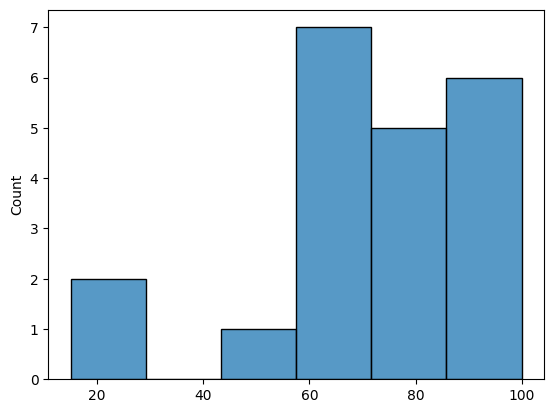

In [9]:
sns.histplot(scores)

<Axes: ylabel='Density'>

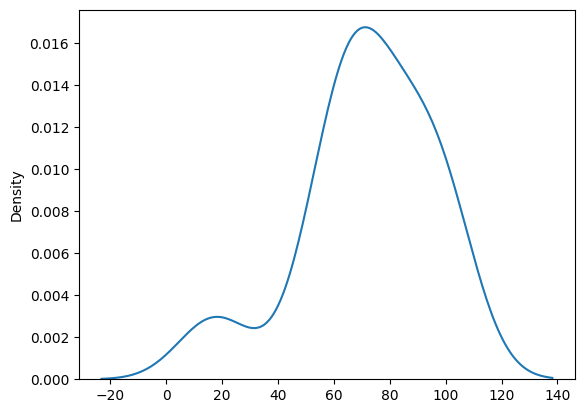

In [10]:
sns.kdeplot(scores)

This data set left skewed. So, I should use IQR method

In [11]:
prices = np.array([30, 32, 35, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 90, 100, 120, 150, 200, 300, 400, 500, 800, 1000, 1200])

<Axes: ylabel='Density'>

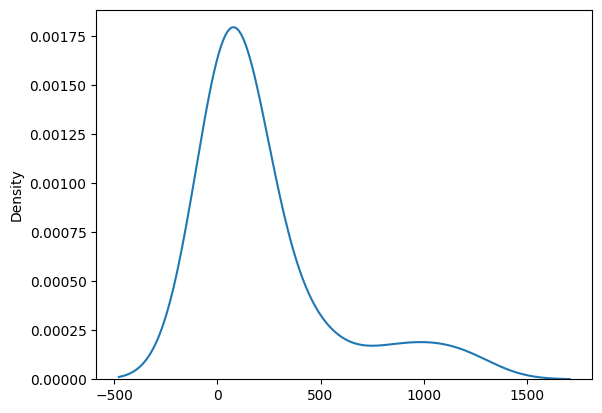

In [12]:
sns.kdeplot(prices)

This data set right skewed. I should use IQR method.

In [13]:
prices_Q1 = np.percentile(prices, 25)
prices_Q3 = np.percentile(prices, 75)

IQR = prices_Q3 - prices_Q1

prices_minimum = max(0, prices_Q1 - 1.5 * IQR)
prices_maximum = prices_Q3 + 1.5 * IQR

prices_outliers = prices[(prices < prices_minimum) | (prices > prices_maximum)]

print(prices_outliers)
print(len(prices_outliers))

[ 500  800 1000 1200]
4


Winsorization

In [14]:
product_ratings = np.array([1, 2, 3, 4, 4, 5, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 1, 2, 10, 10, 10, 0.5, 9.5])

In [15]:
min_range = np.percentile(product_ratings, 5)
max_range = np.percentile(product_ratings, 95)

print(min_range, max_range)

product_ratings = product_ratings.clip(min_range, max_range)

print(product_ratings.max(), product_ratings.min())

1.0 10.0
10.0 1.0


Preserves Sample Size (N): Deleting extreme ratings lowers your total count from 25 to 24. Winsorization keeps all 25 rows intact, protecting statistical power.

Prevents Data Loss: Product reviews like 0.5 still carry valuable sentiment information (it was a very low rating). Capping modifies the extreme value to minimize its distorting effect on downstream calculations (like the mean) without throwing away the user's feedback entirely.

Problem 5: Mixed Methods – Compare Z-Score & IQR on Same Data

In [16]:
mix_data = np.array([12, 15, 18, 20, 22, 22, 23, 24, 25, 25, 26, 27, 28, 30, 32, 35, 38, 40, 45, 50, 55, 60, 65, 70, 80, 90, 100, 120, 150, 200, 500, 1000, 2000])

<Axes: ylabel='Count'>

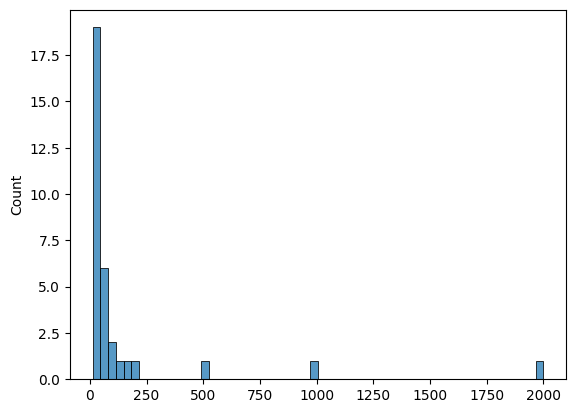

In [17]:
sns.histplot(mix_data)

<Axes: ylabel='Density'>

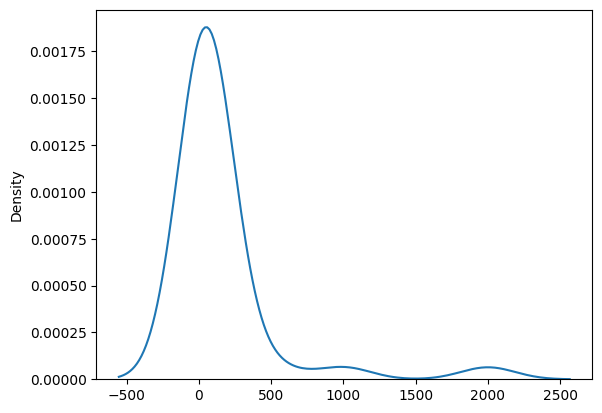

In [18]:
sns.kdeplot(mix_data)

In [19]:
mean_of_mix_data = mix_data.mean()
std_of_mix_data = mix_data.std()

mix_data_z_score = (mix_data - mean_of_mix_data) / std_of_mix_data

print(mix_data_z_score)

[-0.3769789  -0.36895462 -0.36093035 -0.35558083 -0.35023131 -0.35023131
 -0.34755655 -0.34488179 -0.34220703 -0.34220703 -0.33953228 -0.33685752
 -0.33418276 -0.32883324 -0.32348372 -0.31545945 -0.30743517 -0.30208565
 -0.28871186 -0.27533806 -0.26196427 -0.24859047 -0.23521668 -0.22184288
 -0.19509529 -0.1683477  -0.14160012 -0.08810494 -0.00786217  0.12587578
  0.92830345  2.26568291  4.94044182]


In [20]:
out_liers_mix_data = mix_data[abs(mix_data_z_score > 3)]
print(out_liers_mix_data)
print(len(out_liers_mix_data))

[2000]
1


In [21]:
mix_data_Q1 = np.percentile(mix_data, 25)
mix_data_Q3 = np.percentile(mix_data, 75)

IQR = mix_data_Q3 - mix_data_Q1

mix_data_minimum = max(0, mix_data_Q1 - 1.5 * IQR)
mix_data_maximum = mix_data_Q3 + 1.5 * IQR

mix_data_outliers = mix_data[(mix_data < mix_data_minimum) | (mix_data > mix_data_maximum)]

print(mix_data_outliers)
print(len(mix_data_outliers))

[ 200  500 1000 2000]
4


Which method to trust? You must trust the IQR Method for this dataset.

Justification: The Z-score test mathematically requires data to closely follow a symmetrical, standard normal (Gaussian) distribution curve. This dataset represents extreme, non-normal, heavily right-skewed data. Applying the Z-score method on highly skewed data yields flawed threshold evaluations, whereas the IQR method provides an objective mathematical frame robust against distribution imbalances.

Problem 6: Real-World Scenario – Employee Bonus


In [22]:
bonus = np.array([5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 9, 9, 10, 10, 10, 11, 12, 13, 15, 18, 20, 25, 30, 35, 40, 50, 60, 80, 100, 120, 150, 200, 300])

In [23]:
from scipy import stats

mean_of_bonus = np.mean(bonus)
meadian_of_bonus = np.median(bonus)
mode_of_bonus = stats.mode(bonus)[0]

print(mean_of_bonus, meadian_of_bonus, mode_of_bonus)

42.24242424242424 12.0 7


In [24]:
bonus_Q1 = np.percentile(bonus, 25)
bonus_Q3 = np.percentile(bonus, 75)

IQR = bonus_Q3 - bonus_Q1

bonus_minimum = max(0, bonus_Q1 - 1.5 * IQR)
bonus_maximum = bonus_Q3 + 1.5 * IQR

print(bonus_minimum, bonus_maximum)

bonus_outliers = bonus[(bonus < bonus_minimum) | (bonus > bonus_maximum)]

print(bonus_outliers)
print(len(bonus_outliers))

0 88.0
[100 120 150 200 300]
5


In [25]:
min_range = np.percentile(bonus, 3)
max_range = np.percentile(bonus, 97)

print(min_range, max_range)

bonus = bonus.clip(min_range, max_range)

print(bonus.max(), bonus.min())

print(bonus)

5.0 203.99999999999991
203.99999999999991 5.0
[  5.   5.   6.   6.   7.   7.   7.   8.   8.   8.   9.   9.  10.  10.
  10.  11.  12.  13.  15.  18.  20.  25.  30.  35.  40.  50.  60.  80.
 100. 120. 150. 200. 204.]


In [26]:
win_mean_of_bonus = np.mean(bonus)
print(win_mean_of_bonus)

39.333333333333336


Yes it is more resonable